### Гипотеза 6: Аугментации + больше эпох + Label Smoothing

**Идея:** Комбинация трёх техник для борьбы с переобучением на специфике train-набора:
1. **Аугментации** — не дают модели зазубрить train, заставляют учить общие признаки
2. **30 эпох + CosineAnnealingLR** — достаточно времени для сходимости с плавным снижением LR
3. **Label Smoothing (0.1)** — не даёт confidence доходить до 1.0, предотвращает «уверенное переобучение»
4. **AdamW + weight_decay** — регуляризация весов для борьбы с переобучением

Проводим экспиремент для модели `Swin-T`, так как для `ResNet18` уже были проведены эксперименты с аугментациями и Label Smoothing.

Импорт библиотек и загрузка результатов

In [1]:
from common import *
all_results = load_results()

Загрузка параметров и подготовка данных

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # названия классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
SEED = cfg["seed"] # seed
train_indices = cfg["train_indices"] # индексы train
val_indices = cfg["val_indices"] # индексы val

# Аугментированный трансформ для train
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # изменение размера изображения
    transforms.RandomHorizontalFlip(), # случайное горизонтальное отражение
    transforms.RandomRotation(15), # случайное вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # случайные изменения яркости, контраста, насыщенности и оттенка
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # случайные аффинные преобразования
    transforms.ToTensor(), # преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # нормализация
])

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform_aug) # создание train-набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание val-набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание test-набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # выборка train-набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # выборка val-набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание train-loader
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание val-loader
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание test-loader

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция обучения с Label Smoothing + CosineAnnealing

In [ ]:
def train_swin_proper(model, model_name, train_loader, val_loader, test_loader,
                           epochs=30, lr=5e-5, device=DEVICE):
    """ Обучение модели с Label Smoothing + CosineAnnealing + AdamW + warmup """
    set_seed(SEED)
    model = model.to(device) # перенос модели на GPU
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # критерий для обучения
    optimizer = optim.AdamW([
        {'params': model.features.parameters(), 'lr': lr}, # параметры для обучения
        {'params': model.head.parameters(), 'lr': lr * 10} # параметры для обучения верхнего слоя
    ], weight_decay=0.05) # регуляризация весов

    warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=3) # линейный прогрев
    cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # косинусное снижение

    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None # масштабирование градиентов

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # история обучения

    for epoch in range(epochs): # обучение по эпохам

        if epoch < 3:
            warmup.step() # прогрев
        else:
            cosine.step() # косинусное снижение

        model.train() # обучение
        running_loss = 0.0 # потери
        all_preds = [] # предсказания
        all_labels = [] # метки

        for images, labels in train_loader: # обучение по батчам
            images, labels = images.to(device), labels.to(device) # перенос на GPU
            optimizer.zero_grad() # обнуление градиентов

            if scaler: # масштабирование градиентов
                with torch.amp.autocast('cuda'): # автомасштабирование
                    outputs = model(images) # предсказания
                    loss = criterion(outputs, labels) # потери
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.unscale_(optimizer) # отмена масштабирования градиентов
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # ограничение градиентов
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштаба
            else:
                outputs = model(images) # предсказания
                loss = criterion(outputs, labels) # потери
                loss.backward() # обратная связь
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # ограничение градиентов
                optimizer.step() # обновление весов

            running_loss += loss.item() * images.size(0) # потери
            _, preds = torch.max(outputs, 1) # предсказания
            all_preds.extend(preds.cpu().numpy()) # расширение предсказаний
            all_labels.extend(labels.cpu().numpy()) # расширение меток

        train_loss = running_loss / len(train_loader.dataset) # потери
        train_acc = accuracy_score(all_labels, all_preds) # точность

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка на val

        history["train_loss"].append(train_loss) # потери
        history["val_loss"].append(val_loss) # потери
        history["train_acc"].append(train_acc) # точность
        history["val_acc"].append(val_acc) # точность

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
              f"Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    # Оценка на тесте (без label smoothing в criterion)
    test_criterion = nn.CrossEntropyLoss() # критерий для оценки
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, test_criterion, device
    ) # оценка на тесте

    # вывод метрик
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # матрица ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # отчет о классификации
    print(f"{model_name} - Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение результатов
    return {
        "model": model_name,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1,
        "history": history,
        "confusion_matrix": cm.tolist(),
    }

/home/alex/study/4course/Cyberphysics/Lab1/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/20 - Train Loss: 0.7756, Train Acc: 0.7563, Val Loss: 0.4512, Val Acc: 0.9538, Val Bal Acc: 0.9539, Val F1: 0.9539
Epoch 2/20 - Train Loss: 0.4874, Train Acc: 0.9346, Val Loss: 0.6578, Val Acc: 0.8494, Val Bal Acc: 0.8500, Val F1: 0.8350
Epoch 3/20 - Train Loss: 0.4559, Train Acc: 0.9508, Val Loss: 0.3738, Val Acc: 0.9920, Val Bal Acc: 0.9920, Val F1: 0.9920
Epoch 4/20 - Train Loss: 0.4193, Train Acc: 0.9680, Val Loss: 0.3598, Val Acc: 0.9945, Val Bal Acc: 0.9945, Val F1: 0.9945
Epoch 5/20 - Train Loss: 0.3959, Train Acc: 0.9787, Val Loss: 0.3585, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 6/20 - Train Loss: 0.4003, Train Acc: 0.9787, Val Loss: 0.3620, Val Acc: 0.9950, Val Bal Acc: 0.9950, Val F1: 0.9950
Epoch 7/20 - Train Loss: 0.3850, Train Acc: 0.9842, Val Loss: 0.3647, Val Acc: 0.9960, Val Bal Acc: 0.9960, Val F1: 0.9960
Epoch 8/20 - Train Loss: 0.3678, Train Acc: 0.9918, Val Loss: 0.3577, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 9/20 - Tra

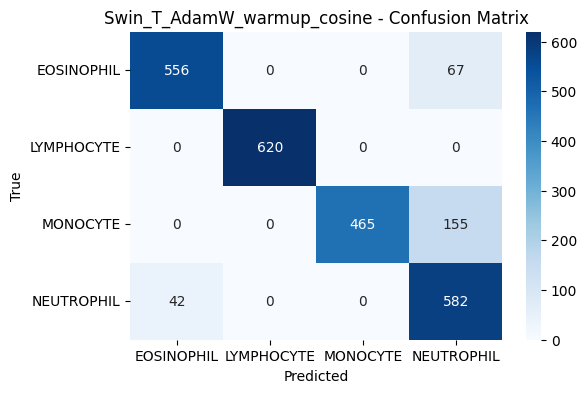

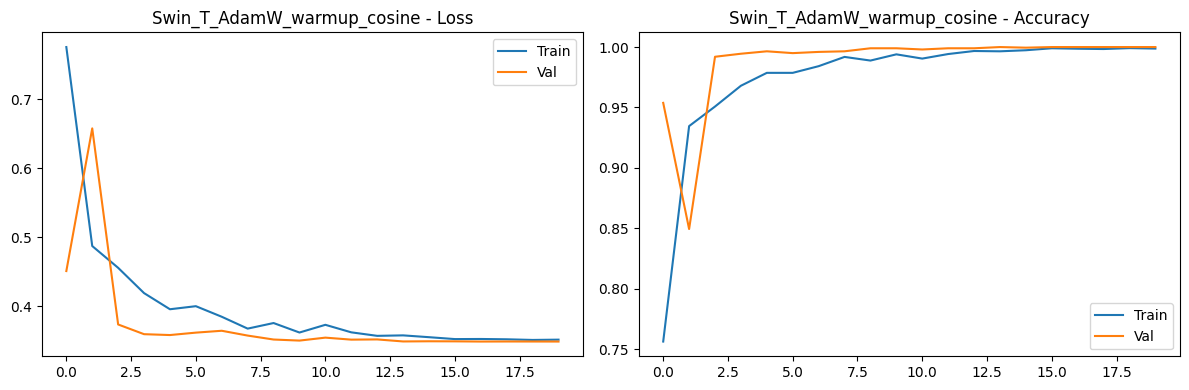

Swin_T_AdamW_warmup_cosine - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.89      0.91       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.72      0.93      0.82       624

    accuracy                           0.89      2487
   macro avg       0.91      0.89      0.90      2487
weighted avg       0.91      0.89      0.90      2487



In [ ]:
model_swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
model_swin.head = nn.Linear(model_swin.head.in_features, len(CLASS_NAMES)) # изменение последнего слоя

result_swin = train_swin_proper(
    model_swin,
    "Swin_T_AdamW_warmup_cosine",
    train_loader, val_loader, test_loader,
    epochs=20,
    lr=5e-5,
)

torch.save(model_swin.state_dict(), "outputs/swin_t_adamw_warmup_cosine_20ep.pth") # сохранение модели

Специально подобранная конфигурация для трансформера достигла Accuracy 0.8938, Balanced Accuracy 0.8938, Macro-F1 0.8957 — прирост +1.36% по сравнению с baseline (0.8802). Гипотеза подтверждена. Ключевую роль сыграли: AdamW с weight_decay=0.05 (классическая регуляризация для трансформеров), раздельные LR для features и head (5e-5 vs 5e-4) и линейный warmup, обеспечивший стабильный старт без больших скачков градиентов. 

Характерный провал на эпохе 2 (val Accuracy ~0.849) — типичный артефакт warmup-фазы — после которого модель быстро восстановилась.

Сохранение результатов

In [ ]:
all_results = load_results()
all_results["Swin_T_adamW_warmup"] = result_swin # добавление результатов в словарь

df_cosine = pd.DataFrame([result_swin]) # создание DataFrame
baseline_models = pd.DataFrame([ 
    all_results["baseline_resnet18"], 
    all_results["baseline_swin"]
]) 

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # создание DataFrame

print("Baseline vs Swin_T_adamW_warmup:") # вывод результатов
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]]) # вывод результатов
save_results(all_results) # сохранение результатов

Baseline vs Swin_T_adamW_warmup:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,Swin_T_AdamW_warmup_cosine,0.893848,0.893787,0.895749


Результаты сохранены в outputs/experiment_results.pkl


Гипотеза подтверждена. Для Swin-T существенен правильный подбор оптимизатора и режима обучения: AdamW + warmup + cosine — стандартная «рецептура» для трансформеров, оказавшаяся эффективной и при fine-tuning на узкоспециализированных данных.